## 辅助函数

In [4]:
import json
import os
import logging
import sys
from datetime import datetime


def load_json(file_path):
    """
    加载 JSON 文件并将其转化为 Python 数据结构（通常是 dict 或 list）。
    
    :param file_path: JSON 文件的路径
    :return: 返回加载后的 Python 数据结构（dict 或 list）
    :raises: FileNotFoundError 如果文件不存在，或 ValueError 如果解析失败
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"文件 {file_path} 不存在。")
    
    with open(file_path, 'r', encoding='utf-8') as json_file:
        try:
            data = json.load(json_file)
            return data
        except json.JSONDecodeError as e:
            raise ValueError(f"解析 JSON 文件失败：{e}")

def save_json(data, file_path):
    """
    将 Python 数据结构保存为 JSON 文件。
    
    :param data: Python 数据结构（通常是 dict 或 list）
    :param file_path: 保存 JSON 文件的路径
    :raises: TypeError 如果数据不是可序列化为 JSON 的类型
    """
    try:
        with open(file_path, 'w', encoding='utf-8') as json_file:
            json.dump(data, json_file, ensure_ascii=False, indent=4)
    except TypeError as e:
        raise ValueError(f"无法将数据保存为 JSON 格式：{e}")


def get_logger(name):
    # 生成带有时间戳的日志文件名
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_dir = "logs"
    log_filename = f"{log_dir}/实验_{timestamp}.log"

    # 如果日志目录不存在，创建该目录
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)

    # 获取或创建 logger
    logger = logging.getLogger(name)

    # 防止重复添加 Handlers
    if not logger.hasHandlers():
        # 创建 FileHandler
        file_handler = logging.FileHandler(log_filename)
        file_handler.setLevel(logging.INFO)
        file_handler.setFormatter(logging.Formatter(
            "[%(asctime)s] [%(name)s] [%(filename)s(%(lineno)d)] [%(levelname)s] %(message)s"
        ))

        # 创建 StreamHandler
        stream_handler = logging.StreamHandler()
        stream_handler.setLevel(logging.INFO)
        stream_handler.setFormatter(logging.Formatter(
            "[%(asctime)s] [%(name)s] [%(filename)s(%(lineno)d)] [%(levelname)s] %(message)s"
        ))

        # 添加 handlers 到 logger
        logger.addHandler(file_handler)
        logger.addHandler(stream_handler)

        # 确保每次日志记录后立即刷新
        for handler in logger.handlers:
            handler.flush = sys.stdout.flush  # 强制刷新控制台输出

    logger.setLevel(logging.INFO)
    
    return logger

## 环境注册器
环境注册器,将环境的实体注册为id来使用,这样就可以直接将环境对象通过大模型进行传递了

In [5]:
# 在脚本的顶层定义 env_registry 作为全局变量
env_registry = {}

# 函数中引用该全局变量
def env_register(env_id, env):
    global env_registry  # 声明使用全局变量
    env_registry[env_id] = env

## 定义工具

In [6]:
import os
import grid2op
from grid2op.PlotGrid import PlotMatplot
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from datetime import datetime
import numpy as np
# 定义实现函数
def set_bus_impl(element_indices: List[int], bus_element_index: int, bus_number: int) -> Dict[str, Any]:
    """
    模拟 set_bus 函数的实现，用于设置 grid2op 环境中的总线设置。
    """
    try:
        # 假设在这里与 grid2op 环境进行交互并返回结果
        logger.info(f"开始设置总线。element_indices: {element_indices}, bus_element_index: {bus_element_index}, bus_number: {bus_number}")
        # ... 在这里写交互代码
        return {
            "status": "success",
            "message": f"Bus {bus_number} set for element {bus_element_index}."
        }
    except Exception as e:
        logger.error(f"设置总线时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"设置总线时出错: {str(e)}"
        }


def set_bus(arguments: Dict[str, Any]) -> Dict[str, Any]:
    try:
        element_indices = arguments["element_indices"]
        bus_element_index = arguments["bus_element_index"]
        bus_number = arguments["bus_number"]
        logger.info(f"接收到设置总线请求。参数: {arguments}")
        result = set_bus_impl(element_indices, bus_element_index, bus_number)
        return result
    except Exception as e:
        logger.error(f"处理set_bus请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理set_bus请求时出错: {str(e)}"
        }


def line_change_status_impl(env_id, line_indices: List[int]) -> Dict[str, Any]:
    """
    修改电力线的状态。如果电力线已连接，则尝试断开；如果断开，则尝试连接。
    """
    try:
        # 通过env_id来寻找正确的env    
        env = env_registry.get(env_id)
        if not env:
            raise ValueError(f"环境 ID 为 {env_id} 的环境未找到。")
        
        logger.info(f"开始修改电力线状态。env_id: {env_id}, line_indices: {line_indices}")
        
        # 模拟修改电力线状态
        env.action_space.line_change_status = line_indices
        
        logger.info(f"成功修改电力线状态: {line_indices}")
        return {
            "status": "success",
            "message": f"电力线 {line_indices} 状态已修改。",
        }
    except Exception as e:
        logger.error(f"修改电力线状态时出错: {str(e)}")
        return {
            "status": "failure",
            "message": str(e)
        }


def line_change_status(arguments: Dict[str, Any]) -> Any:
    try:
        env_id = arguments.get("env_id")
        line_indices = arguments.get("line_indices")
        logger.info(f"接收到修改电力线状态请求。参数: {arguments}")
        result = line_change_status_impl(env_id, line_indices)
        return result
    except Exception as e:
        logger.error(f"处理line_change_status请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理line_change_status请求时出错: {str(e)}"
        }


def plot_layout_by_name_impl(env_name) -> Dict[str, Any]:
    """
    使用 PlotMatplot 的 plot_layout 方法来绘制电网布局。
    """
    try:
        logger.info(f"开始绘制电网布局，环境名称: {env_name}")
        env = grid2op.make(env_name)
        plot_helper = PlotMatplot(env.observation_space)
        fig_layout = plot_helper.plot_layout()
        fig_layout.savefig('grid_layout.png')
        logger.info("电网布局绘制成功，并保存为 'grid_layout.png'")
        plt.show()  # 添加这一行 可以直接在过程中显示在jupyterlab里
        return {
            "status": "success",
            "message": "电网布局绘制成功。",
        }
    except Exception as e:
        logger.error(f"绘制电网布局时出错: {str(e)}")
        return {
            "status": "failure",
            "message": str(e)
        }


def plot_layout_by_name(arguments: Dict[str, Any]) -> Any:
    try:
        env_name = arguments.get("env_name")
        logger.info(f"接收到绘制电网布局请求，环境名称: {env_name}")
        result = plot_layout_by_name_impl(env_name)
        return result
    except Exception as e:
        logger.error(f"处理plot_layout_by_name请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理plot_layout_by_name请求时出错: {str(e)}"
        }


def plot_layout_by_env_id_impl(env_id) -> Dict[str, Any]:
    """
    使用 PlotMatplot 的 plot_layout 方法来绘制电网布局。
    """
    try:
        logger.info(f"开始根据环境 ID 绘制电网布局，env_id: {env_id}")
        env = env_registry.get(env_id)
        plot_helper = PlotMatplot(env.observation_space)
        fig_layout = plot_helper.plot_layout()
        fig_layout.savefig('grid_layout.png')
        logger.info("电网布局绘制成功，并保存为 'grid_layout.png'")
        # 主动显示图像
        plt.show()  # 添加这一行
        return {
            "status": "success",
            "message": "电网布局绘制成功。",
        }
    except Exception as e:
        logger.error(f"绘制电网布局时出错: {str(e)}")
        return {
            "status": "failure",
            "message": str(e)
        }


def plot_layout_by_env_id(arguments: Dict[str, Any]) -> Any:
    try:
        env_id = arguments.get("env_id")
        logger.info(f"接收到绘制电网布局请求，env_id: {env_id}")
        result = plot_layout_by_env_id_impl(env_id)
        return result
    except Exception as e:
        logger.error(f"处理plot_layout_by_env_id请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理plot_layout_by_env_id请求时出错: {str(e)}"
        }


def redispatch(arguments: Dict[str, Any]) -> Any:
    try:
        env_id = arguments.get("env_id")
        gen_id = arguments.get("gen_id")
        amount = arguments.get("amount")
        logger.info(f"接收到redispatch请求，env_id: {env_id}, gen_id: {gen_id}, amount: {amount}")
        
        # 确保 amount 是一个列表
        if not isinstance(amount, list):
            amount = [amount]
        
        if len(gen_id) > 1 and len(amount) == 1:
            amount = amount * len(gen_id)
        
        result = redispatch_impl(env_id, gen_id, amount)
        return result
    except Exception as e:
        logger.error(f"处理redispatch请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理redispatch请求时出错: {str(e)}"
        }


def redispatch_impl(env_id, gen_id: List[int], amount: List[int]) -> Dict[str, Any]:
    try:
        logger.info(f"开始执行redispatch操作，env_id: {env_id}, gen_id: {gen_id}, amount: {amount}")
        env = env_registry.get(env_id)
        if env is None:
            raise ValueError(f"无法找到 env_id 为 {env_id} 的环境实例。")
        
        # 检查是否允许进行重分配操作
        if not env.redispatching_unit_commitment_availble:
            raise ValueError("当前环境不允许进行发电机功率重分配操作。")
        
        # 遍历每个发电机，检测是否可进行重分配
        for g_id in gen_id:
            if not env.gen_redispatchable[g_id]:
                raise ValueError(f"发电机 {g_id} 不允许进行功率重分配。")
        
        param = [(g_id, a) for g_id, a in zip(gen_id, amount)]
        action = env.action_space({"redispatch": param})  # 执行功率重分配

        if action.is_ambiguous()[0]:
            info = action.ambiguous_info()[1]
            raise ValueError(f"动作是模糊的，无法执行。{info}")
        else:
            env.step(action)
            logger.info("成功进行发电机功率重分配。")
            return {
                "status": "success",
                "message": "成功进行发电机功率重分配。"
            }
    except Exception as e:
        logger.error(f"redispatch_impl 执行失败: {str(e)}")
        return {
            "status": "failure",
            "message": f"redispatch_impl 执行失败: {str(e)}"
        }


def curtail(arguments: Dict[str, Any]) -> Any:
    try:
        env_id = arguments.get("env_id", "env")
        gen_id = arguments.get("gen_id")
        amount_ratio = arguments.get("amount_ratio")
        logger.info(f"接收到curtail请求，env_id: {env_id}, gen_id: {gen_id}, amount_ratio: {amount_ratio}")
        
        # 确保 gen_id 和 amount_ratio 都被提供
        if gen_id is None or amount_ratio is None:
            raise ValueError("缺少必需的参数: gen_id 或 amount_ratio。")

        if not isinstance(amount_ratio, list):
            amount_ratio = [amount_ratio]

        if len(gen_id) > 1 and len(amount_ratio) == 1:
            amount_ratio = amount_ratio * len(gen_id)

        result = curtail_impl(env_id, gen_id, amount_ratio)
        return result
    except Exception as e:
        logger.error(f"处理curtail请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理curtail请求时出错: {str(e)}"
        }


def curtail_impl(env_id, gen_id: List[int], amount_ratio: List[float]) -> Dict[str, Any]:
    try:
        logger.info(f"开始执行curtail操作，env_id: {env_id}, gen_id: {gen_id}, amount_ratio: {amount_ratio}")
        env = env_registry.get(env_id)
        if env is None:
            raise ValueError(f"无法找到 env_id 为 {env_id} 的环境实例。")

        param = [(g_id, ratio) for g_id, ratio in zip(gen_id, amount_ratio)]
        action = env.action_space({"curtail": param})

        if action.is_ambiguous()[0]:
            info = action.ambiguous_info()[1]
            raise ValueError(f"动作是模糊的，无法执行。{info}")
        else:
            env.step(action)
            logger.info("成功进行发电削减操作。")
            return {
                "status": "success",
                "message": "成功进行发电削减操作。"
            }
    except Exception as e:
        logger.error(f"curtail_impl 执行失败: {str(e)}")
        return {
            "status": "failure",
            "message": f"curtail_impl 执行失败: {str(e)}"
        }


def plot_obs_by_env_id_impl(env_id) -> Dict[str, Any]:
    """
    使用 PlotMatplot 的 plot_obs 方法来绘制电网的观测状态。
    """
    try:
        # 通过env_id来寻找正确的env    
        env = env_registry.get(env_id)
        
        if env is None:
            raise ValueError(f"无法找到 env_id 为 {env_id} 的环境实例。")

        # 获取当前环境的观测值，不需要调用 reset
        obs = env.get_obs()

        # 创建 PlotMatplot 实例
        plot_helper = PlotMatplot(env.observation_space)
        
        # 调用 plot_obs 方法，显示线的功率信息和负载的电压信息
        fig_obs = plot_helper.plot_obs(obs, line_info="p", load_info="v")

        # 保存图片
        folder_name = "images"
        if not os.path.exists(folder_name):
            os.makedirs(folder_name)

        # 增加到毫秒级时间戳
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")[:-3]  # 精确到毫秒
        filename = f"plot_{timestamp}.png"
        file_path = os.path.join(folder_name, filename)
        
        fig_obs.savefig(file_path)
        logger.info(f"电网观测状态绘制成功，并保存为 {file_path}")
        
        return {
            "status": "success",
            "message": "电网观测状态绘制成功。"
        }
    except Exception as e:
        logger.error(f"绘制电网观测状态时出错: {str(e)}")
        return {
            "status": "failure",
            "message": str(e)
        }

def plot_obs_by_env_id(arguments: Dict[str, Any]) -> Any:
    try:
        env_id = arguments.get("env_id")
        logger.info(f"接收到绘制电网观测状态请求，env_id: {env_id}")
        result = plot_obs_by_env_id_impl(env_id)
        return result
    except Exception as e:
        logger.error(f"处理plot_obs_by_env_id请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理plot_obs_by_env_id请求时出错: {str(e)}"
        }

## 定义函数映射

In [7]:
# 映射工具名称到执行函数对
tool_map = {
    "set_bus": set_bus,
    "line_change_status": line_change_status,
    "plot_layout_by_name":plot_layout_by_name,
    "plot_layout_by_env_id":plot_layout_by_env_id,
    "redispatch":redispatch,
    "curtail":curtail,
    "plot_obs_by_env_id":plot_obs_by_env_id
}

## 创造/处理模型消息
这部分函数主要是创造和处理大模型产生的信息

In [8]:
# 封装消息生成函数
def create_message(content: str) -> List[Dict[str, str]]:
    """
    创建消息。
    """
    # 和模型对话发送信息
    messages = [
        {"role": "system",
         "content": "你是人工智能助手。"},
        {"role": "user", "content": content}  # 用户输入
    ]
    logger.info(f"创建消息: {content}")
    return messages

# 消息处理函数，将大模型的函数调用以及执行进行封装
def process_tool_calls(client, tool_map, llm_model, tools: List[Dict[str, Any]], messages: List[Dict[str, str]],**kwargs) -> str:
    #TODO: 考虑处理多个大模型的调用指令,然后用投票的方式选择执行哪一个
    """
    处理工具调用。

    函数的主要目的是根据工具映射和工具列表中的信息，调用相应的工具对象，并处理返回的结果。
    最后，函数将返回一个字符串，表示处理结果。

    Args:
        client (_type_): 客户端对象，用于与后端服务进行通信。
        tool_map (_type_): 工具映射，将工具名称映射到相应的工具对象。
        tools (List[Dict[str, Any]]): 工具列表，包含要处理的工具调用信息。
        messages (List[Dict[str, str]]): 消息列表，包含与工具调用相关的消息。

    Returns:
        str: 处理结果，表示工具调用是否成功以及相应的结果信息。
    """

    finish_reason = None
    i = 0
    # 向大模型发送指令和工具集合
    model = llm_model
    logger.info(f"开始处理工具调用，使用的模型为: {model}")
    while finish_reason is None or finish_reason == "tool_calls":
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=kwargs.get("temperature", 0.1),
                tools=tools,  # 提交定义好的工具
            )
        except Exception as e:
            logger.error(f"与大模型通信时出错: {str(e)}")
            return f"与大模型通信时出错: {str(e)}"

        # 得到回复后提取finish_reason,并检查是否是工具调用
        choice = completion.choices[0]
        finish_reason = choice.finish_reason
        logger.info(f"接收到模型的回复，finish_reason: {finish_reason}")

        if finish_reason == "tool_calls":  # 判断是否有工具调用
            logger.info(f"模型进行了工具调用, 序号 {i}，工具调用信息: {choice.message}")
            messages.append(choice.message)  # 添加工具调用消息到上下文

            for tool_call in choice.message.tool_calls:  # 处理多个工具调用
                tool_call_name = tool_call.function.name
                logger.info(f"执行序号 [{i}]，调用工具名称: {tool_call_name}")

                if choice.message.content:
                    logger.info(f"执行序号 [{i}]，模型解释工具调用原因: {choice.message.content}")

                tool_call_arguments = json.loads(tool_call.function.arguments)
                logger.info(f"执行序号 [{i}]，函数调用参数: {tool_call_arguments}")

                tool_function = tool_map[tool_call_name]
                logger.info(f"执行序号 [{i}]，正在执行工具函数: {tool_function.__name__}")

                try:
                    tool_result = tool_function(tool_call_arguments)
                    logger.info(f"执行序号 [{i}]，工具函数执行结果: {tool_result}")
                except Exception as e:
                    logger.error(f"执行工具函数时出错: {str(e)}")
                    tool_result = {"status": "failure", "message": f"工具执行失败: {str(e)}"}

                i += 1  # 显示执行次数

                # 判断工具调用的结果并生成消息
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "name": tool_call_name,
                    "content": json.dumps(tool_result),  # 使用 json.dumps 将执行结果序列化成字符串
                })

                # 可以手动设置其他的原因来遮盖失败的实际问题
                # if tool_result["status"] == "success":
                #     messages.append({
                #         "role": "tool",
                #         "tool_call_id": tool_call.id,
                #         "name": tool_call_name,
                #         "content": json.dumps(tool_result),
                #     })
                # elif tool_result["status"] == "failure":
                #     messages.append({
                #         "role": "tool",
                #         "tool_call_id": tool_call.id,
                #         "name": tool_call_name,
                #         "content": json.dumps({"status": "failure", "message": tool_result["message"]}),
                #     })
                # else:
                #     messages.append({
                #         "role": "tool",
                #         "tool_call_id": tool_call.id,
                #         "name": tool_call_name,
                #         "content": json.dumps({"status": "Unknown", "message": tool_result["message"]}),
                #     })

    # 最终输出
    # logger.info(f"模型的最终回复: {choice.message.content}")
    return choice.message.content


## 主函数

[2024-10-22 11:22:17,665] [__main__] [17305273.py(18)] [INFO] 成功导入 LightSimBackend 用于更快的后端计算。
[2024-10-22 11:22:17,667] [__main__] [17305273.py(26)] [INFO] 主流程开始执行。
[2024-10-22 11:22:17,667] [__main__] [17305273.py(30)] [INFO] 参数初始化完成。
[2024-10-22 11:22:17,758] [__main__] [17305273.py(38)] [INFO] OpenAI 客户端初始化成功，已连接到 DeepSeek API。
[2024-10-22 11:22:17,759] [__main__] [17305273.py(47)] [INFO] 模型和最大迭代次数设置完成，模型: deepseek-chat，最大迭代次数: 20。
[2024-10-22 11:22:18,687] [__main__] [17305273.py(53)] [INFO] 环境 'l2rpn_case14_sandbox' 创建成功，使用后端: LightSimBackend。
[2024-10-22 11:22:18,688] [__main__] [17305273.py(62)] [INFO] 环境 'test1' 注册成功。
[2024-10-22 11:22:18,689] [__main__] [2908890092.py(12)] [INFO] 创建消息: 请你使用我提供给你的工具,首先画出env_id为"test1"的状态观测图，一共有6个发电机，编号从0到5
                                  然后将1号发电机功率提升10Mw，再然后画出当前环境id为'test1'的状态观测图。
                                  然后请你再把除了发电机1,2，3，4以外所有的发电机的功率降低5Mw，请你一次只调控一个发电机，
                                  此外如果有多个工具调用，
                                  

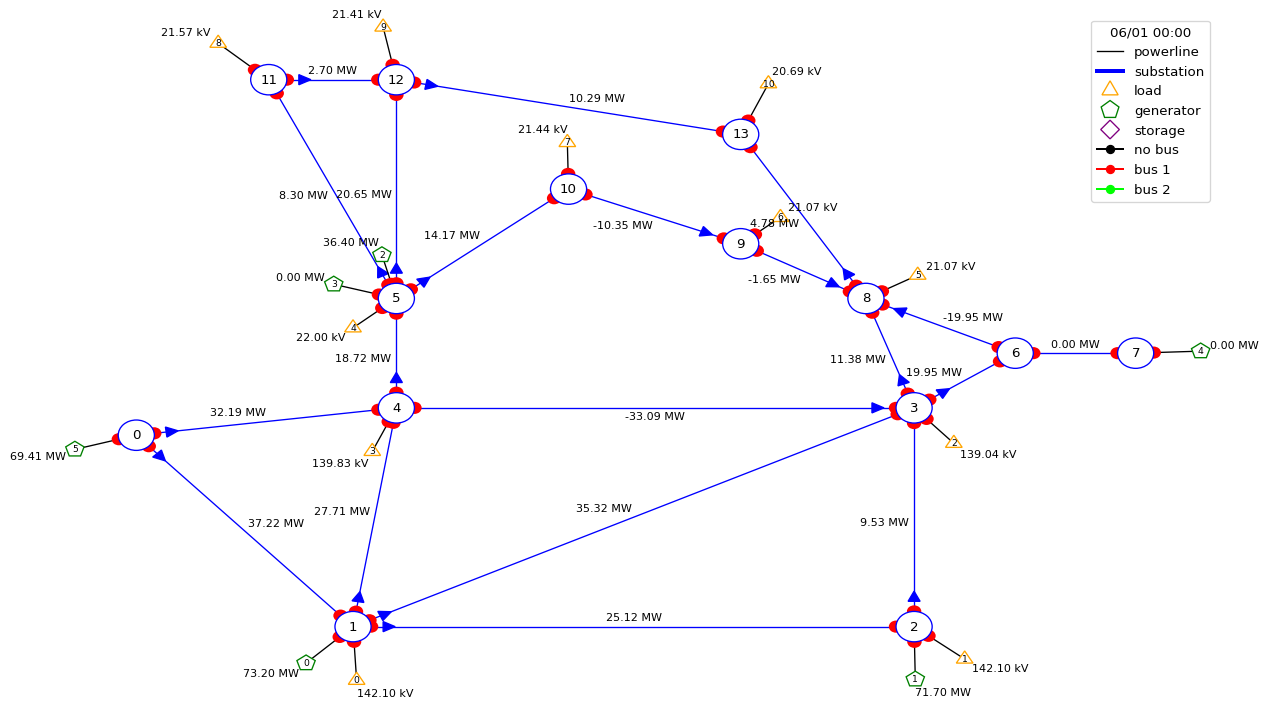

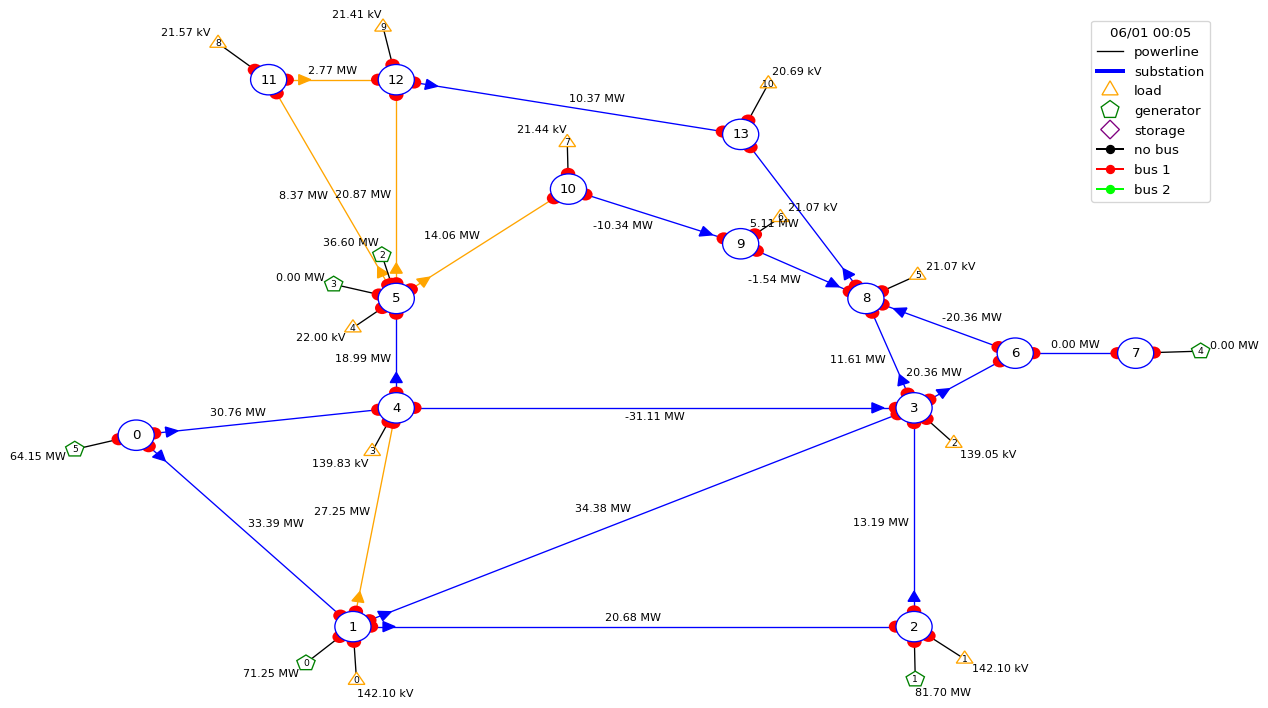

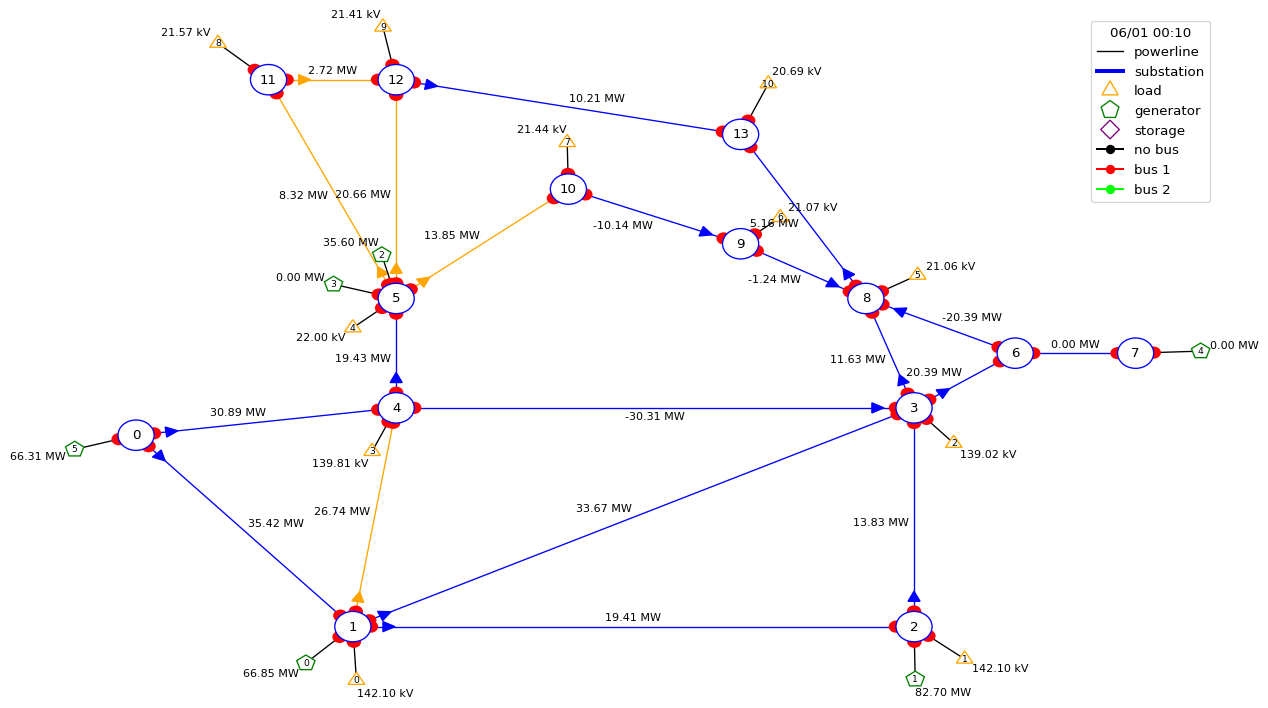

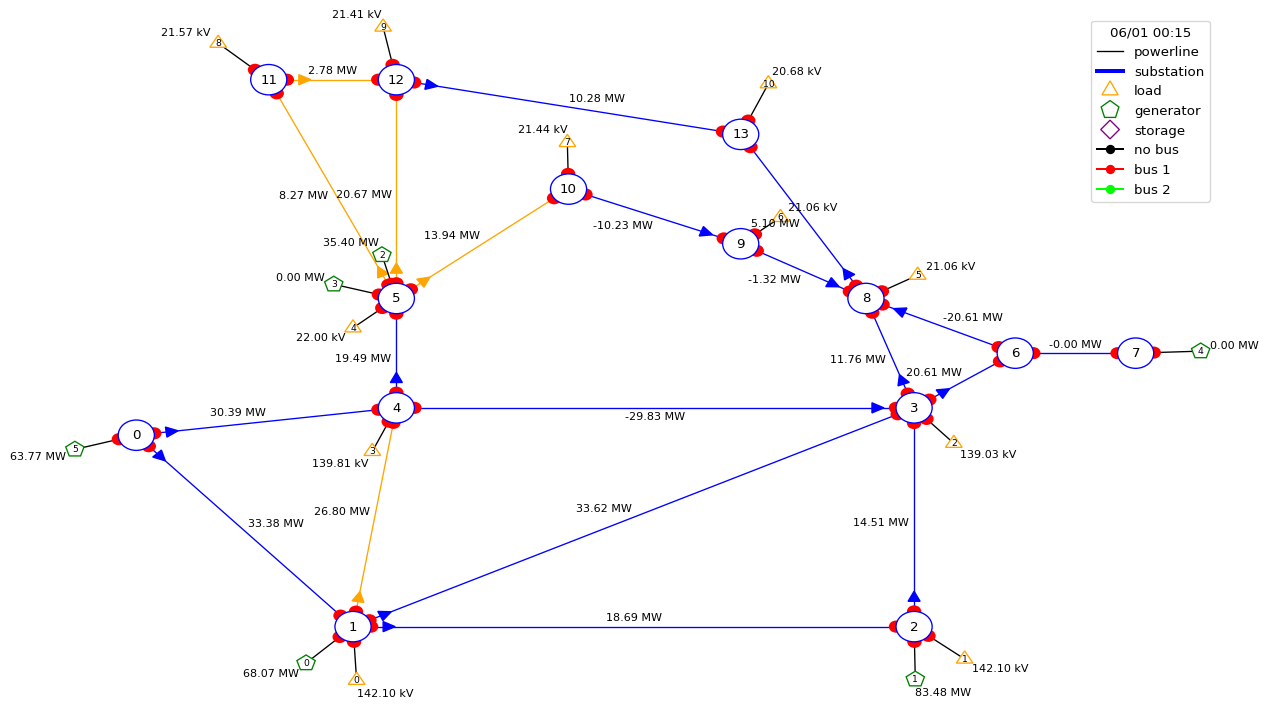

In [9]:
import sys
import os
import grid2op
from grid2op.PlotGrid import PlotMatplot
from grid2op.Action import PlayableAction
from grid2op.Parameters import Parameters
from openai import OpenAI

# 可选：在Jupyter Notebook中显示Matplotlib绘图
%matplotlib inline

# 设置日志记录器，或者简单使用print函数
logger = get_logger(__name__)

try:
    from lightsim2grid import LightSimBackend
    bk_cls = LightSimBackend
    logger.info("成功导入 LightSimBackend 用于更快的后端计算。")
except ImportError as exc:
    logger.warning(f"导入 LightSimBackend 时发生错误：{exc}，将使用 PandaPowerBackend 作为后备方案。")
    from grid2op.Backend import PandaPowerBackend
    bk_cls = PandaPowerBackend

# 主流程
if __name__ == "__main__":
    logger.info("主流程开始执行。")

    # 初始化参数
    param = Parameters()
    logger.info("参数初始化完成。")

    # 初始化OpenAI客户端
    try:
        client = OpenAI(
            api_key="",  # deepseek api
            base_url="https://api.deepseek.com"  # 使用 deepseek 模型
        )
        logger.info("OpenAI 客户端初始化成功，已连接到 DeepSeek API。")
    except Exception as e:
        logger.error(f"OpenAI 客户端初始化失败，错误信息：{e}")
        sys.exit(1)

    # 设置模型和最大迭代次数
    model_moonshot = "moonshot-v1-8k"
    model_deepseek = "deepseek-chat"
    max_iter = 20
    logger.info(f"模型和最大迭代次数设置完成，模型: {model_deepseek}，最大迭代次数: {max_iter}。")

    # 设置环境
    env_name = "l2rpn_case14_sandbox"
    try:
        env = grid2op.make(env_name, action_class=PlayableAction, param=param, backend=bk_cls())
        logger.info(f"环境 '{env_name}' 创建成功，使用后端: {bk_cls.__name__}。")
    except Exception as e:
        logger.error(f"创建环境 '{env_name}' 失败，错误信息：{e}")
        sys.exit(1)

    # 生成唯一环境标识符并注册
    env_id = "test1"
    try:
        env_register(env_id, env)
        logger.info(f"环境 '{env_id}' 注册成功。")
    except Exception as e:
        logger.error(f"注册环境 '{env_id}' 失败，错误信息：{e}")
        sys.exit(1)

    # 创建要发送的消息
    try:
        messages = create_message("""请你使用我提供给你的工具,首先画出env_id为"test1"的状态观测图，一共有6个发电机，编号从0到5
                                  然后将1号发电机功率提升10Mw，再然后画出当前环境id为'test1'的状态观测图。
                                  然后请你再把除了发电机1,2，3，4以外所有的发电机的功率降低5Mw，请你一次只调控一个发电机，
                                  此外如果有多个工具调用，
                                  请你在每次调用一次工具后都画出当前环境id为'test1'的状态观测图。
                                  ，如果有任何一步失败，请你告诉我详细的失败原因是什么,
                                  后告知我调用的原因""")
        logger.info("消息内容创建成功。")
    except Exception as e:
        logger.error(f"创建消息失败，错误信息：{e}")
        sys.exit(1)

    # 加载工具
    try:
        tools = load_json('tools.json')
        logger.info("工具信息加载成功。")
    except Exception as e:
        logger.error(f"加载工具信息失败，错误信息：{e}")
        sys.exit(1)

    # 调用工具处理函数
    try:
        final_response = process_tool_calls(client, tool_map, model_deepseek, tools, messages, temperature=0.15)
        logger.info("工具调用成功，已处理所有工具调用逻辑。")
        logger.info(f"模型的最终回复：\n{final_response}")
    except Exception as e:
        logger.error(f"处理工具调用时发生错误，错误信息：{e}")
        sys.exit(1)

# 下面要开始厉害的了,使用langgraph构建应用

## 首先要定义状态结构

In [ ]:
from typing import List, Optional
from typing_extensions import TypedDict,List, Optional
from grid2op.Action import BaseAction
from grid2op.Observation import BaseObservation
from grid2op.Environment import Environment
from grid2op.Parameters import Parameters
from pydantic import BaseModel, field_validator, ValidationError
from langchain_core.messages import BaseMessage, SystemMessage

# 用于预测下一个agent的动作选择是什么
class Prediction(TypedDict):
    action: str
    args: Optional[List[str]]

class AgentState(BaseModel):
    env_id: str
    actions: List[BaseAction]  # 已执行的动作
    observations: List[BaseObservation]= Field(default_factory=list)  # 当前的环境观察状态
    scratchpad: List[BaseMessage] = Field(default_factory=list)
    prediction: Prediction
    
    # 在 pydantic 的模型配置中启用 arbitrary_types_allowed，
    # 允许 pydantic 接受任意类型的字段而不尝试生成模式
    # class Config:
    #     arbitrary_types_allowed = True
        
    # # 验证 actions，确保每个动作都是 BaseAction 的实例
    # @field_validator('actions')
    # @classmethod
    # def check_actions(cls, action):
    #     """确保 actions 列表中的每个动作都是 BaseAction 类型"""
    #     if not isinstance(action, BaseAction):
    #         raise ValueError(f"Action 必须是 BaseAction 类型，而不是 {type(action)}")
    #     return action

    # # 验证 observation，确保 observation 是 BaseObservation 的实例
    # @field_validator('observation')
    # @classmethod
    # def check_observation(cls, observation):
    #     """确保 observation 是 BaseObservation 类型"""
    #     if observation is not None and not isinstance(observation, BaseObservation) for observation in observations:
    #         raise ValueError(f"Observation 必须是 BaseObservation 类型，而不是 {type(observation)}")
    #     return observation
    
    # # 验证 env，确保 env 是 Environment 类型
    # @field_validator('env', mode='before')
    # @classmethod
    # def check_env(cls, env):
    #     """确保 env_id 是str 类型"""
    #     if not isinstance(env, str):
    #         raise ValueError(f"env_id 需要是字符串类型")
    #     return env
        

## 定义工具

In [ ]:
import sys
import logging
import numpy as np
import uuid
import matplotlib.pyplot as plt

#首先定义工具节点
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

import grid2op
from typing import List, Dict, Any
from datetime import datetime
from grid2op.PlotGrid import PlotMatplot
from grid2op.Action import PlayableAction
from grid2op.Parameters import Parameters


# 设置日志配置
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 在脚本的顶层定义 env_registry 作为全局变量
env_registry = {}
# 函数中引用该全局变量
def env_register(env_id, env):
    global env_registry  # 声明使用全局变量
    env_registry[env_id] = env


### 定义环境创建工具，这样可以初始化环境

In [ ]:
import uuid
from grid2op.Parameters import Parameters
from grid2op.Action import PlayableAction
import grid2op

# 假设已经定义了 logger
import logging
logger = logging.getLogger(__name__)

def create_environment(env_name, env_id=None, param=None, bk_cls=None):
    """
    创建并注册一个grid2op环境，并选择合适的后端。

    参数：
    - env_name: str，环境名称。
    - env_id: str, 环境注册id，默认为None，也可由用户指定
    - param: dict，传递给环境的参数，默认为Parameters()。
    - bk_cls: class，后端类，默认为LightSimBackend。

    返回：
    - dict: 包含创建状态、消息和环境数据的字典
    """
  
    try:
        # 如果没有传入 env_id，则生成一个唯一的 UUID 作为环境 ID
        env_id = env_id or str(uuid.uuid4())

        # 设置默认参数
        param = param or Parameters()  # 确保param有默认值

        # 默认选择后端
        if bk_cls is None:
            try:
                from lightsim2grid import LightSimBackend
                bk_cls = LightSimBackend
                logger.info("成功导入 LightSimBackend，用于更快的后端计算。")
            except ImportError as exc:
                logger.warning(f"导入 LightSimBackend 时发生错误：{exc}，将使用 PandaPowerBackend 作为后备方案。")
                from grid2op.Backend import PandaPowerBackend
                bk_cls = PandaPowerBackend

        # 设置环境
        env = grid2op.make(env_name, action_class=PlayableAction, param=param, backend=bk_cls())
        logger.info(f"环境 '{env_name}' 创建成功，使用后端: {bk_cls.__name__}。")
    
        # 检查并初始化环境注册器
        global env_registry
        if 'env_registry' not in globals():
            env_registry = {}
            logger.info("环境注册器未定义，已初始化 env_registry。")
        
        # 注册环境 (确保 env_register 函数已经定义)
        env_registry[env_id] = env
        logger.info(f"环境 '{env_id}' 注册成功。")

        return {
            "status": "success",
            "message": f"环境 '{env_name}' 创建并注册成功。",
            "data": {"env": env, "env_id": env_id}
        }

    except Exception as e:
        logger.error(f"创建或注册环境 '{env_name}' 失败，错误信息：{str(e)}")
        return {
            "status": "failure",
            "message": f"创建或注册环境时出错: {str(e)}",
            "data": None
        }

In [ ]:

def get_obs_by_id(env_id: str) -> Dict[str, Any]:
    """
    根据环境的注册ID获取grid2op环境的当前状态。
    
    参数:
    - env_id: str, 环境的注册ID

    返回:
    - Dict[str, Any]: 包含状态和当前环境信息的字典
    """
    try:
        # 1. 检查是否已注册该环境
        if env_id not in env_registry:
            raise ValueError(f"环境ID {env_id} 未注册，无法获取状态。")
        
        # 2. 获取已注册的环境对象
        env = env_registry[env_id]
        
        # 3. 获取当前的观测状态
        observation = env.get_obs()  # 获取当前观测状态
        
        # 4. 提取观测状态并格式化为易于理解的字典
        observation_data = {
            "gen_p": observation.prod_p.tolist(),  # 发电机有功功率
            "gen_q": observation.prod_q.tolist(),  # 发电机无功功率
            "gen_v": observation.prod_v.tolist(),  # 发电机电压
            "gen_theta": observation.gen_theta.tolist(),  # 发电机相位角
            "load_p": observation.load_p.tolist(),  # 负载有功功率
            "load_q": observation.load_q.tolist(),  # 负载无功功率
            "load_v": observation.load_v.tolist(),  # 负载电压
            "load_theta": observation.load_theta.tolist(),  # 负载相位角
            "p_or": observation.p_or.tolist(),  # 线路一端有功功率
            "q_or": observation.q_or.tolist(),  # 线路一端无功功率
            "v_or": observation.v_or.tolist(),  # 线路一端电压
            "a_or": observation.a_or.tolist(),  # 线路一端相位角
            "theta_or": observation.theta_or.tolist(),  # 线路一端角度
            "p_ex": observation.p_ex.tolist(),  # 线路另一端有功功率
            "q_ex": observation.q_ex.tolist(),  # 线路另一端无功功率
            "v_ex": observation.v_ex.tolist(),  # 线路另一端电压
            "a_ex": observation.a_ex.tolist(),  # 线路另一端相位角
            "theta_ex": observation.theta_ex.tolist(),  # 线路另一端角度
            "rho": observation.rho.tolist(),  # 线路上的功率流（rho）
            "topo_vect": observation.topo_vect.tolist(),  # 拓扑结构
            "line_status": observation.line_status.tolist(),  # 线路状态 (1: 正常, 0: 断开)
        }
        
        # 5. 返回成功状态和观测数据
        return {
            "status": "success",
            "message": "环境状态获取成功",
            "data": observation_data
        }
    
    except Exception as e:
        # 处理异常并返回失败信息
        return {
            "status": "failure",
            "message": f"获取环境状态时出错: {str(e)}",
            "data": None
        }

### 定义画图工具

In [ ]:
def plot_layout_by_env_id_impl(env_id) -> Dict[str, Any]:
    """
    使用 PlotMatplot 的 plot_layout 方法来绘制电网布局。
    """
    try:
        logger.info(f"开始根据环境 ID 绘制电网布局，env_id: {env_id}")
        env = env_registry.get(env_id)
        plot_helper = PlotMatplot(env.observation_space)
        fig_layout = plot_helper.plot_layout()
        fig_layout.savefig('grid_layout.png')
        logger.info("电网布局绘制成功，并保存为 'grid_layout.png'")
        # 主动显示图像
        plt.show()  # 添加这一行
        return {
            "status": "success",
            "message": "电网布局绘制成功。",
        }
    except Exception as e:
        logger.error(f"绘制电网布局时出错: {str(e)}")
        return {
            "status": "failure",
            "message": str(e)
        }

@tool
def plot_layout_by_env_id(arguments: Dict[str, Any]) -> Any:
    """
    根据提供的环境ID绘制电网布局图。

    该工具用于接收一个包含环境ID的参数，并通过内部函数实现绘制指定电网环境的布局图。生成的图像将保存到指定的路径，并返回操作结果。

    Args:
        arguments (Dict[str, Any]): 包含以下键值的字典:
            - "env_id" (str): 环境ID，用于标识需要绘制布局的电网环境。

    Returns:
        Any: 返回一个包含操作结果的字典，字典结构如下：
            - "status" (str): 操作状态，"success" 或 "failure"。
            - "message" (str): 描述操作结果的信息。
    
    Raises:
        Exception: 当绘图或其他操作失败时，捕获异常并返回相应的错误信息。
    """
    try:
        env_id = arguments.get("env_id")
        logger.info(f"接收到绘制电网布局请求，env_id: {env_id}")
        result = plot_layout_by_env_id_impl(env_id)
        return result
    except Exception as e:
        logger.error(f"处理plot_layout_by_env_id请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理plot_layout_by_env_id请求时出错: {str(e)}"
        }

### 定义功率重分配工具

In [ ]:
@tool 
def redispatch(arguments: Dict[str, Any]) -> Dict[str, Any]:
    """
    根据提供的发电机ID和调整量进行功率重分配，并返回操作结果。

    该工具接收一个包含环境ID、发电机ID和功率调整量的参数，执行功率重分配操作。生成的结果将返回成功或失败信息。

    Args:
        arguments (Dict[str, Any]): 包含以下键值的字典:
            - "env_id" (str): 环境ID，用于标识需要进行功率调整的电网环境。
            - "gen_id" (List[int]): 发电机ID的列表，指定需要调整的发电机编号。
            - "amount" (Union[float, List[float]]): 调整量，可以是单个浮点数，也可以是与发电机ID一一对应的列表。如果提供单个浮点数，且有多个发电机，则将该调整量应用到所有发电机。

    Returns:
        Dict[str, Any]: 返回包含操作结果的字典，结构如下:
            - "status" (str): 操作状态，"success" 或 "failure"。
            - "message" (str): 描述操作结果的信息。
            - "data" (Any): 如果成功，返回相应数据，否则为 None。
    """
    try:
        env_id = arguments.get("env_id")
        gen_id = arguments.get("gen_id")
        amount = arguments.get("amount")

        logger.info(f"接收到 redispatch 请求，env_id: {env_id}, gen_id: {gen_id}, amount: {amount}")
        
        # 确保 amount 是一个列表
        if not isinstance(amount, list):
            amount = [amount]
        
        # 如果有多个发电机而只有一个调整量，则应用到所有发电机
        if len(gen_id) > 1 and len(amount) == 1:
            amount = amount * len(gen_id)
        
        # 获取环境对象
        env = env_registry.get(env_id)
        if env is None:
            raise ValueError(f"无法找到 env_id 为 {env_id} 的环境实例。")
        
        # 检查是否允许进行重分配操作
        if not env.redispatching_unit_commitment_availble:
            raise ValueError("当前环境不允许进行发电机功率重分配操作。")
        
        # 遍历发电机，检测是否可进行重分配
        for g_id in gen_id:
            if not env.gen_redispatchable[g_id]:
                raise ValueError(f"发电机 {g_id} 不允许进行功率重分配。")
        
        # 执行功率重分配操作
        param = [(g_id, a) for g_id, a in zip(gen_id, amount)]
        action = env.action_space({"redispatch": param})

        if action.is_ambiguous()[0]:
            info = action.ambiguous_info()[1]
            raise ValueError(f"动作是模糊的，无法执行。{info}")
        else:
            env.step(action)
            logger.info("成功进行发电机功率重分配。")
            return {
                "status": "success",
                "message": "成功进行发电机功率重分配。",
                "data": {"action": str(action)}
            }

    except Exception as e:
        logger.error(f"处理 redispatch 请求时出错: {str(e)}")
        return {
            "status": "failure",
            "message": f"处理 redispatch 请求时出错: {str(e)}",
            "data": None
        }

## 定义工具节点

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode

tools = [create_environment,get_obs_by_id,\
         plot_layout_by_env_id,redispatch]
tool_node = ToolNode(tools)
#下面定义tool_node 使用的模型是哪个
model_with_tools = ChatOpenAI(model="deepseek-chat",
                              openai_api_base="https://api.deepseek.com/beta",
                              openai_api_key=""
                             ).bind_tools(tools)
# TODO 这里可以定义多个模型然后后续进行投票机制的制定


### 在这里测试一下直接调用

调用成功会直接使用函数来绘制图像，而不用使用json定义的工具了，模型现在是通过工具的docstring来理解工具的作用的，而docstring可以方便地使用大模型给生成。

In [ ]:
tool_node.invoke({"messages": [model_with_tools.invoke("初始化名为'l2rpn_case14_sandbox'的环境,并利用返回的id绘制电路图")]})

发现直接执行会因为执行速度问题动作顺序紊乱, 画图的动作会在环境创建完成前开始

## 定义智能体

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI


def parse(text: str) -> dict:
    action_prefix = "Action: "
    if not text.strip().split("\n")[-1].startswith(action_prefix):
        return {"action": "retry", "args": f"无法处理大模型输出: {text}"}
    action_block = text.strip().split("\n")[-1]

    action_str = action_block[len(action_prefix) :]
    split_output = action_str.split(" ", 1)
    if len(split_output) == 1:
        action, action_input = split_output[0], None
    else:
        action, action_input = split_output
    action = action.strip()
    if action_input is not None:
        action_input = [
            inp.strip().strip("[]") for inp in action_input.strip().split(";")
        ]
    return {"action": action, "args": action_input}


from langchain_core.prompts.chat import ChatPromptTemplate
from langchain_core.prompts.chat import MessagesPlaceholder, HumanMessagePromptTemplate, SystemMessagePromptTemplate

# 定义系统消息
system_message = SystemMessagePromptTemplate.from_template(
    """
    你是一个负责管理电网环境的智能代理，使用 grid2op API 执行任务。
    你的任务包括创建电网环境、初始化环境图、绘制电网布局、以及进行发电机功率的重新分配。

    可用的操作包括：
    - "create_environment": 创建一个新的 grid2op 环境并设置后端参数。
    - "initialize_graph": 根据注册的环境 ID 初始化 grid2op 环境，并提取观测结果。
    - "plot_grid": 绘制当前电网布局并保存图像。
    - "redispatch": 根据电网状态重新分配发电机的功率。

    每个操作会包含环境 ID、发电机 ID 或功率调整量等输入。
    
    你需要根据当前电网的状态选择合适的操作并执行。

    每次执行操作后，更新系统的观测结果，确保电网的稳定性并平衡电力管理。

    """
)
# 定义用户输入消息的提示
user_message = HumanMessagePromptTemplate.from_template(
    """
    {user_input}
    """
)

# 构建最终的提示模板
prompt = ChatPromptTemplate.from_messages([system_message, user_message])
glm_4 = ChatOpenAI(model="glm-4", temperature=0.95,
                   openai_api_base="https://open.bigmodel.cn/api/paas/v4/",openai_api_key="")

agent = RunnablePassthrough.assign(
    prediction = prompt | glm_4 | StrOutputParser() | parse
)


## 定义图

In [ ]:
import re

def update_action_records(state: AgentState, result: Dict[str, Any]):
    """
    记录每个动作的返回结果（字典形式），并将其记录到 scratchpad 中。
    
    Args:
        state (AgentState): 代理的当前状态，包含 actions 和 scratchpad。
        result (Dict[str, Any]): 当前动作的返回结果字典，包含 status 和 message 等信息。

    Returns:
        AgentState: 返回更新后的状态。
    """
    old_records = state.scratchpad

    # 更新 scratchpad
    if old_records:
        txt = old_records[0].content  # 获取上一次的记录
        last_line = txt.rsplit("\n", 1)[-1]
        step = int(last_line.split(".")[0]) + 1  # 提取步骤并递增
    else:
        txt = "Action records:\n"
        step = 1

    # 将当前动作的结果记录下来
    txt += f"\n{step}. Status: {result['status']}, Message: {result['message']}"
    
    # 更新 scratchpad，存储新的 SystemMessage
    state.scratchpad = [SystemMessage(content=txt)]

    env = registry[state.env_id]
    current_observation=env.get_obs()
    state.observations.append(current_observation)
    
    if result['data']['action'] is not None:
        state.actions.append(result['data']['action'])
    
    return state

In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import Literal
from langsmith import traceable
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, START, StateGraph

graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent",agent)
graph_builder.add_edge("update_action_records","agent")


tool_nodes = {"create_environment": create_environment,
              "initialize_graph":initialize_grid2op_environment_by_id,
              "plot_grid":plot_layout_by_env_id,
              "redispatch":redispatch}



for node_name, tool in tool_nodes.items():
    graph_builder.add_node(
        node_name,
        # The lambda ensures the function's string output is mapped to 
        # the "observation"
        # key in the AgentState
        RunnableLambda(tool) | (lambda observation: {"observation": observation}),
    )
    # Always return to the agent (by means of the update-scratchpad node)
    graph_builder.add_edge(node_name, "update_action_records")



def select_tool(state: AgentState):
    # Any time the agent completes, this function
    # is called to route the output to a tool or
    # to the end user.
    action = state["prediction"]["action"]
    if action == "ANSWER":
        return END
    if action == "retry":
        return "agent"
    return action

graph_builder.add_conditional_edges("agent", select_tool)



graph = graph_builder.compile()

from IPython.display import Image, display


display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in app.stream(
    {"messages": [("human", "初始化名为'l2rpn_case14_sandbox'的环境,并利用返回的id绘制电路图")]},
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()